In [1]:
# 04_results_visualization.ipynb
# Purpose: Create final report-ready visualizations from modeling results.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_file = Path("../data/concrete_featurized.csv")

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1030, 12)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,w_c_ratio,log_age,w_c_ratio_bin
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0.300000,3.332205,0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,3.332205,0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,0.685714,5.598422,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,0.685714,5.899897,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,0.966767,5.886104,7


In [3]:
model_results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Random Forest"],
    "Mean MAE": [5.905440, 5.904012, 6.135266],
    "Mean R2": [0.727310, 0.727612, 0.674819]
})

model_results

,Model,Mean MAE,Mean R2
0,Ridge,5.905440,0.727310
1,Lasso,5.904012,0.727612
2,Random Forest,6.135266,0.674819


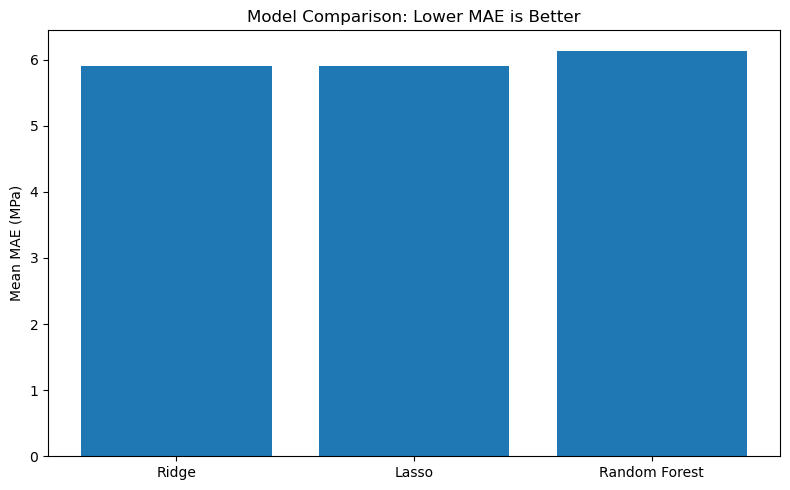

In [4]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["Mean MAE"])
plt.ylabel("Mean MAE (MPa)")
plt.title("Model Comparison: Lower MAE is Better")
plt.tight_layout()
plt.show()

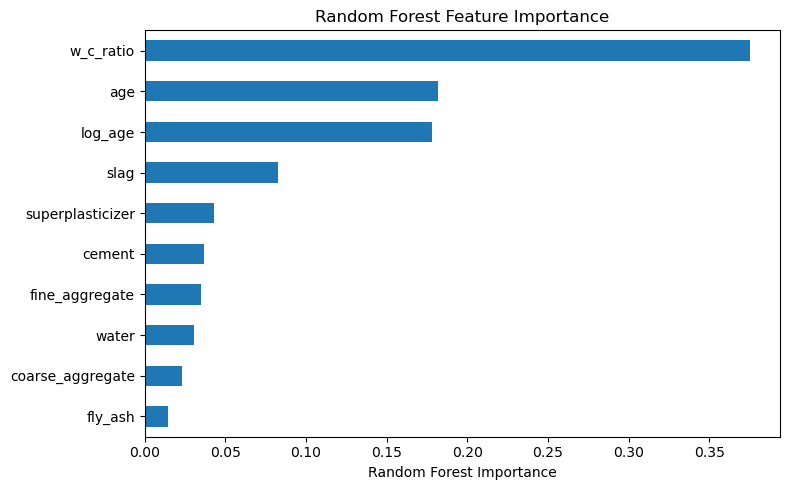

In [5]:
feature_importance = pd.Series({
    "w_c_ratio": 0.375122,
    "age": 0.181771,
    "log_age": 0.177857,
    "slag": 0.082329,
    "superplasticizer": 0.042982,
    "cement": 0.037055,
    "fine_aggregate": 0.034675,
    "water": 0.030759,
    "coarse_aggregate": 0.023276,
    "fly_ash": 0.014175
})

plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Random Forest Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

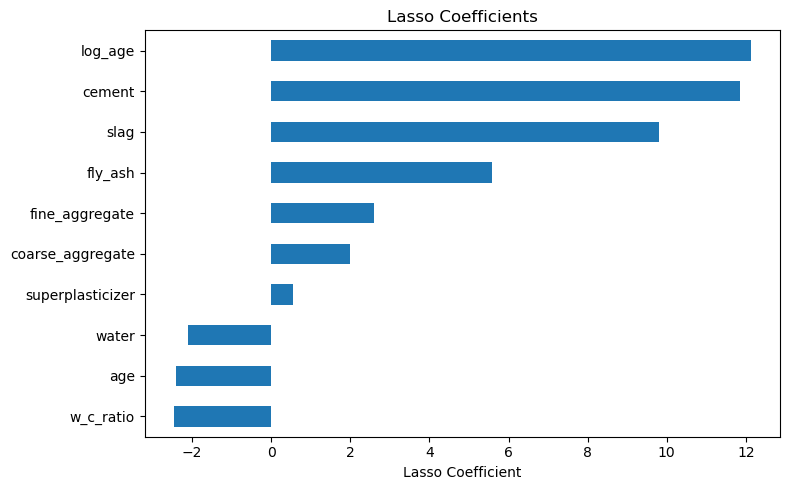

In [6]:
lasso_coefficients = pd.Series({
    "log_age": 12.133152,
    "cement": 11.839796,
    "slag": 9.796828,
    "fly_ash": 5.574294,
    "fine_aggregate": 2.610182,
    "w_c_ratio": -2.467309,
    "age": -2.407992,
    "water": -2.098797,
    "coarse_aggregate": 1.994663,
    "superplasticizer": 0.552624
})

plt.figure(figsize=(8,5))
lasso_coefficients.sort_values().plot(kind="barh")
plt.xlabel("Lasso Coefficient")
plt.title("Lasso Coefficients")
plt.tight_layout()
plt.show()

## Results Summary

The final model comparison showed that Lasso achieved the lowest mean MAE and highest mean R² under 5-fold GroupKFold cross-validation grouped by water-to-cement ratio decile. Ridge performed nearly identically, while Random Forest performed slightly worse under the grouped validation strategy. This suggests that the engineered physical features, especially water-to-cement ratio and logarithmic curing age, allowed simpler linear models to generalize effectively.

Random Forest feature importance identified water-to-cement ratio, age, and log(age) as the most important predictors. Lasso coefficients also confirmed that log(age), cement, slag, fly ash, and water-to-cement ratio remained meaningful predictors. These results are physically reasonable because compressive strength is strongly controlled by curing time, cementitious binder content, and water-to-cement ratio.